In [11]:
import pandas as pd
df = pd.read_csv(r"C:\Users\shash\OneDrive\Desktop\ShashiDoccs\Projects\ChurnIQ\data\Raw\customer_churn_1M.csv")
df.shape
df.head()
df.info()
df["churn"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  str    
 1   signup_date                  1000000 non-null  str    
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  str    
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  str    
 6   marital_status               1000000 non-null  str    
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  str    
 10  payment_method               1000000 non-null  str    
 11  paperless_billing            1000000 non-null  str    
 12  senior_citizen               1000000 non-null  int64  

churn
0    0.900773
1    0.099227
Name: proportion, dtype: float64

In [12]:
import pandas as pd
import time

start = time.time()
df = pd.read_csv(r"C:\Users\shash\OneDrive\Desktop\ShashiDoccs\Projects\ChurnIQ\data\Raw\customer_churn_1M.csv")   # use your actual filename
print(f"Loaded in {time.time() - start:.1f}s")
print(df.shape)
df.info(memory_usage="deep")

Loaded in 3.4s
(1000000, 32)
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  str    
 1   signup_date                  1000000 non-null  str    
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  str    
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  str    
 6   marital_status               1000000 non-null  str    
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  str    
 10  payment_method               1000000 non-null  str    
 11  paperless_billing            1000000 non-null  str    
 12  senior_citizen           

In [6]:
df.select_dtypes("object").nunique()   # which columns have few unique values?

for col in df.select_dtypes("object").columns:
    if df[col].nunique() < 50:
        df[col] = df[col].astype("category")

df.info(memory_usage="deep")   # compare with before

C:\Users\shash\AppData\Local\Temp\ipykernel_20112\3516855717.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").nunique()   # which columns have few unique values?
C:\Users\shash\AppData\Local\Temp\ipykernel_20112\3516855717.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyd

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   customer_id                  1000000 non-null  str     
 1   signup_date                  1000000 non-null  str     
 2   age                          1000000 non-null  int64   
 3   gender                       1000000 non-null  category
 4   annual_income                970041 non-null   float64 
 5   education                    1000000 non-null  category
 6   marital_status               1000000 non-null  category
 7   dependents                   1000000 non-null  int64   
 8   tenure                       1000000 non-null  int64   
 9   contract                     1000000 non-null  category
 10  payment_method               1000000 non-null  category
 11  paperless_billing            1000000 non-null  category
 12  senior_citizen               1000000 non

In [7]:
df["churn"].value_counts(normalize=True)
df.isna().sum().sort_values(ascending=False).head(10) # how many missing values in each column?


avg_monthly_gb           50012
credit_score             40395
annual_income            29959
num_complaints           29906
customer_satisfaction    19921
customer_id                  0
age                          0
signup_date                  0
tenure                       0
contract                     0
dtype: int64

In [8]:
df.describe()

,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
count,1000000.000000,970041.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.00000,1000000.000000,980079.000000,970094.000000,1000000.000000,1000000.000000,949988.000000,1000000.000000,959605.000000,1000000.000000
mean,44.724603,58788.311936,0.799831,22.381923,0.199511,86.443701,1837.321438,2.563721,0.769551,0.849742,...,0.59999,0.549086,6.159110,0.701667,1.760248,0.400969,39.095179,44.494191,678.562134,0.099227
std,14.479468,37137.433079,0.893654,20.073341,0.399633,27.592430,1803.721634,1.412330,0.421120,0.357324,...,0.48990,0.497585,2.328287,0.838148,1.485677,0.633289,43.852564,44.922587,87.642951,0.298967
min,18.000000,20000.000000,0.000000,1.000000,0.000000,20.000000,16.300000,1.000000,0.000000,0.000000,...,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,300.000000,0.000000
25%,34.000000,32712.560000,0.000000,6.000000,0.000000,70.490000,484.530000,1.000000,1.000000,1.000000,...,0.00000,0.000000,4.000000,0.000000,1.000000,0.000000,12.840000,12.000000,619.000000,0.000000
50%,44.000000,48954.600000,1.000000,16.000000,0.000000,85.480000,1249.750000,2.000000,1.000000,1.000000,...,1.00000,1.000000,7.000000,1.000000,1.000000,0.000000,27.770000,31.000000,680.000000,0.000000
75%,55.000000,73475.130000,1.000000,33.000000,0.000000,100.680000,2617.660000,3.000000,1.000000,1.000000,...,1.00000,1.000000,8.000000,1.000000,3.000000,1.000000,51.230000,62.000000,740.000000,0.000000
max,90.000000,250000.000000,5.000000,72.000000,1.000000,854.956730,16252.861508,6.000000,1.000000,1.000000,...,1.00000,1.000000,9.000000,7.000000,12.000000,5.000000,557.824023,365.000000,850.000000,1.000000


In [9]:
# Churn rate by category — the single most useful EDA pattern for classification
for col in df.select_dtypes("category").columns:
    print(df.groupby(col, observed=True)["churn"].mean().sort_values(ascending=False), "\n")

gender
Male      0.099279
Female    0.099217
Other     0.098226
Name: churn, dtype: float64 

education
master         0.099981
bachelor       0.099509
high_school    0.099123
phd            0.099085
college        0.098566
Name: churn, dtype: float64 

marital_status
divorced    0.099801
married     0.099623
single      0.098797
widowed     0.096967
Name: churn, dtype: float64 

contract
month_to_month    0.265056
one_year          0.126531
two_year          0.056519
Name: churn, dtype: float64 

payment_method
electronic_check    0.099478
bank_transfer       0.099436
credit_card         0.099086
mailed_check        0.098788
Name: churn, dtype: float64 

paperless_billing
No     0.099908
Yes    0.099000
Name: churn, dtype: float64 



<Axes: xlabel='tenure', ylabel='Density'>

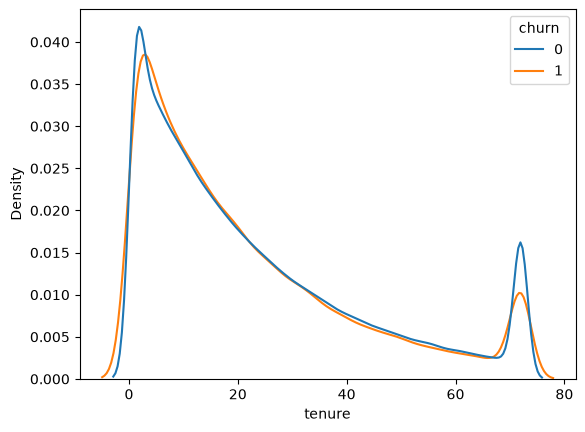

In [10]:
# Numeric features split by churn
import seaborn as sns
sns.kdeplot(data=df, x="tenure", hue="churn", common_norm=False)